In [1]:
setwd("/scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant")

## Libraries

In [2]:
library(here)
library(glue)
library(tidyverse)
library(ComplexHeatmap)
library(grid)
library(circlize)   
library(Seurat)
library(SingleCellExperiment)
library(SpatialExperiment)
library(HDF5Array)
library(dplyr)

here() starts at /scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: grid

ComplexHeatmap version 2.26.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex hea

## Setup

In [3]:
source(here("misc/paths.R"))

Rows: 20 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (17): donor_id, study_id, disease_group, sex, age, sars-cov-2_antemortem...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Load data

In [4]:
tcr_df <- "{tcr_sp}/tcrs-meb.tsv" %>%
    glue() %>%
    here() %>%
    readr::read_tsv(file = .) %>% data.frame()
tcr_df <- tcr_df %>%
  dplyr::rename(cond_tissue = study_id_tissue) %>%
  mutate(tissue = case_when(str_detect(tolower(cond_tissue), "lung") ~ "lung",
                            str_detect(tolower(cond_tissue), "lymph-node") ~ "lymph-node",
                            TRUE ~ "unknown"),
         condition = case_when(str_detect(tolower(cond_tissue), "control") ~ "control",
                               str_detect(tolower(cond_tissue), "acute") ~ "acute",
                               str_detect(tolower(cond_tissue), "chronic") ~ "chronic",
                               str_detect(tolower(cond_tissue), "prolonged") ~ "prolonged",
                               TRUE ~ "unknown"))

se <- "{sc_data}/lung_autopsy_all.rds" %>%
  glue::glue() %>%
  here::here() %>%
  readRDS(.)
sce <- as.SingleCellExperiment(se)
spe <- loadHDF5SummarizedExperiment("~/SP-COVID/visium/0-processing/out/0-QC_before_spe")

Rows: 1345 Columns: 42
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (30): tagValueCELL, targetSequences, targetQualities, allVHitsWithScore,...
dbl (10): cloneId, readCount, uniqueMoleculeCount, minQualFR1, minQualCDR1, ...
lgl  (2): allCHitsWithScore, allCAlignments

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
sce_meta <- tibble(
    donor_id     = unique(sce$donor),
    disease_group = sce$condition[match(unique(sce$donor), sce$donor)]) %>%
    dplyr::mutate(disease_group = dplyr::recode(disease_group, akut = "acute"))

true_tcr <- sample_metadata %>%
    dplyr::filter(tcr_id %in% unique(tcr_df$orig)) %>%
    dplyr::distinct(donor_id, tissue)

all_donors <- union(union(unique(sample_metadata$donor_id), sce_meta$donor_id),
                    unique(true_tcr$donor_id))

meta <- tibble(donor_id = all_donors) %>%
    dplyr::left_join(
        sample_metadata %>%
            dplyr::select(donor_id, disease_group, sex, age) %>%
            dplyr::distinct(donor_id, .keep_all = TRUE),
        by = "donor_id") %>%
    dplyr::left_join(sce_meta, by = "donor_id", suffix = c("", "_sce")) %>%
    dplyr::mutate(disease_group = dplyr::coalesce(disease_group, disease_group_sce)) %>%
    dplyr::select(-disease_group_sce) %>%
    dplyr::mutate(donor_id = factor(donor_id,
        levels = c("O448", "S198", "S188", "17B", "BB73", "S293", "T128", "O325",
                   "A329", "S317", "A333", "A344", "S208", "S267", "A592", "T188"))) %>%
    dplyr::arrange(donor_id)

donors <- meta$donor_id
n <- length(donors)

spe_coldata <- as.data.frame(colData(spe)) %>%
    separate(donor_tissue, into = c("donor_id", "tissue_parsed"),
             sep = "-", extra = "merge")

spe_lung <- spe_coldata %>% dplyr::filter(tissue == "lung")
spe_ln <- spe_coldata %>% dplyr::filter(tissue == "lymph-node")

st_lung_summary <- spe_lung %>%
    dplyr::group_by(donor_id) %>%
    dplyr::summarise(
        median_features = median(detected, na.rm = TRUE),
        n_spots = dplyr::n(),
        .groups = "drop")

st_ln_summary <- spe_ln %>%
    dplyr::group_by(donor_id) %>%
    dplyr::summarise(
        median_features = median(detected, na.rm = TRUE),
        n_spots = dplyr::n(),
        .groups = "drop")

sce_coldata <- as.data.frame(colData(sce))

sn_lung_summary <- sce_coldata %>%
    dplyr::group_by(donor) %>%
    dplyr::summarise(
        median_features = median(nFeature_RNA, na.rm = TRUE),
        n_cells = dplyr::n(),
        .groups = "drop") %>%
    dplyr::rename(donor_id = donor)

tcr_with_donor <- tcr_df %>%
    dplyr::left_join(
        sample_metadata %>% dplyr::select(tcr_id, donor_id),
        by = c("orig" = "tcr_id"))

n_unmatched <- sum(is.na(tcr_with_donor$donor_id))
if (n_unmatched > 0)
    warning(sprintf("%d tcr_df rmissmatch", n_unmatched))

tcr_lung_summary <- tcr_with_donor %>%
    dplyr::filter(tissue == "lung") %>%
    dplyr::count(donor_id, name = "n_tcr_rows")

tcr_ln_summary <- tcr_with_donor %>%
    dplyr::filter(tissue == "lymph-node") %>%
    dplyr::count(donor_id, name = "n_tcr_rows")

get_metric <- function(summary_df, metric_col, donors) {
    vals <- summary_df[[metric_col]][match(as.character(donors), summary_df$donor_id)]
    setNames(vals, as.character(donors))
}

minmax_norm <- function(x) {
    rng <- range(x, na.rm = TRUE)
    if (diff(rng) == 0) return(rep(0.5, length(x)))
    (x - rng[1]) / diff(rng)
}

minmax_fixed <- function(x, rng) {
    if (diff(rng) == 0) return(rep(0.5, length(x)))
    (x - rng[1]) / diff(rng)
}

lung_features_raw <- get_metric(st_lung_summary, "median_features", donors)
lung_nspots_raw <- get_metric(st_lung_summary, "n_spots", donors)
sn_features_raw <- get_metric(sn_lung_summary, "median_features", donors)
sn_ncells_raw <- get_metric(sn_lung_summary, "n_cells", donors)
tcr_lung_raw <- get_metric(tcr_lung_summary, "n_tcr_rows", donors)

ln_features_raw <- get_metric(st_ln_summary, "median_features", donors)
ln_nspots_raw <- get_metric(st_ln_summary, "n_spots", donors)
tcr_ln_raw <- get_metric(tcr_ln_summary, "n_tcr_rows", donors)

shared_range_features <- range(c(lung_features_raw, ln_features_raw), na.rm = TRUE)
shared_range_nspots <- range(c(lung_nspots_raw, ln_nspots_raw), na.rm = TRUE)
shared_range_tcr_rows <- range(c(tcr_lung_raw, tcr_ln_raw), na.rm = TRUE)

m_lung <- rbind(
  "Median features (ST)" = minmax_fixed(lung_features_raw, shared_range_features),
  "# Spots" = minmax_fixed(lung_nspots_raw, shared_range_nspots),
  "Median features (snRNA-seq)" = minmax_norm(sn_features_raw),
  "# Cells" = minmax_norm(sn_ncells_raw),
  "# Rows" = minmax_fixed(tcr_lung_raw, shared_range_tcr_rows))
colnames(m_lung) <- as.character(donors)

m_ln <- rbind(
  "Median features (ST)" = minmax_fixed(ln_features_raw, shared_range_features),
  "# Spots" = minmax_fixed(ln_nspots_raw, shared_range_nspots),
  "TCR n rows" = minmax_fixed(tcr_ln_raw, shared_range_tcr_rows))
colnames(m_ln) <- as.character(donors)

m_lung_raw <- rbind(
    "Median features (ST)" = lung_features_raw,
    "# Spots" = lung_nspots_raw,
    "Median features (snRNA-seq)" = sn_features_raw,
    "# Cells" = sn_ncells_raw,
    "# Rows" = tcr_lung_raw)

m_ln_raw <- rbind(
    "Median features (ST)" = ln_features_raw,
    "# Spots" = ln_nspots_raw,
    "# Rows" = tcr_ln_raw)

dg_col <- c(control = "#0E088D", acute = "#8A00AE", chronic = "#DD3978", prolonged = "#FF8F20")
sex_col <- c(f = "#ED93B1", m = "#85B7EB")
age_col <- c("40-44" = "#EAF3DE", "45-49" = "#C0DD97", "50-54" = "#C0DD97",
             "55-59" = "#97C459", "60-64" = "#639922", "65-69" = "#3B6D11",
             "70-74" = "#27500A", "75-79" = "#27500A",
             "80-84" = "#085041", "85-89" = "#085041", "90-94" = "#04342C")

col_st  <- colorRamp2(c(0, 1), c("#FFF7BC", "#CC4C02"))
col_sn  <- colorRamp2(c(0, 1), c("#C7EAE5", "#01665E"))
col_tcr <- colorRamp2(c(0, 1), c("#FDDBC7", "#B2182B")) 

col_split <- factor(meta$disease_group,
                    levels = c("control", "acute", "chronic", "prolonged"))

cell_size <- unit(6, "mm")

ht_lung <- Heatmap(m_lung,
    rect_gp = gpar(type = "none"),
    cluster_rows = FALSE, cluster_columns = FALSE, cluster_column_slices = FALSE,
    column_split = col_split, column_title = " ",
    column_title_side = "top",
    column_title_gp = gpar(fontsize = 10, fontface = "bold"),
    show_column_names = FALSE,
    row_names_side = "left", row_names_gp = gpar(fontsize = 8),
    width  = unit(n * 6, "mm"),
    height = unit(nrow(m_lung) * 6, "mm"),
    show_heatmap_legend = FALSE,
    cell_fun = function(j, i, x, y, w, h, fill) {
    rn  <- rownames(m_lung)[i]
    pal <- if (rn %in% c("Median features (ST)", "# Spots")) col_st
           else if (rn %in% c("Median features (snRNA-seq)", "# Cells")) col_sn
           else col_tcr
    val <- m_lung[i, j]
    grid.rect(x, y, w, h,
        gp = gpar(fill = if (is.na(val)) "white" else pal(val),
                  col = "white", lwd = 0.5))})

ht_ln <- Heatmap(m_ln,
    rect_gp = gpar(type = "none"),
    cluster_rows = FALSE, cluster_columns = FALSE, cluster_column_slices = FALSE,
    column_split = col_split,
    column_title_side = "top",
    column_title_gp = gpar(fontsize = 10, fontface = "bold"),
    show_column_names = FALSE,
    row_names_side = "left", row_names_gp = gpar(fontsize = 8),
    width  = unit(n * 6, "mm"),
    height = unit(nrow(m_ln) * 6, "mm"),
    show_heatmap_legend = FALSE,
    cell_fun = function(j, i, x, y, w, h, fill) {
    rn  <- rownames(m_ln)[i]
    pal <- if (rn %in% c("Median features (ST)", "# Spots")) col_st else col_tcr
    val <- m_ln[i, j]
    grid.rect(x, y, w, h,
        gp = gpar(fill = if (is.na(val)) "white" else pal(val),
                  col = "white", lwd = 0.5))})

ha_meta <- HeatmapAnnotation(
    "Disease stage" = anno_simple(meta$disease_group, col = dg_col, na_col = "white",
                                  pch = ifelse(is.na(meta$disease_group), 4, NA)),
    Sex = anno_simple(meta$sex, col = sex_col, na_col = "white",
                      pch = ifelse(is.na(meta$sex), 4, NA)),
    Age = anno_simple(meta$age, col = age_col, na_col = "white",
                      pch = ifelse(is.na(meta$age), 4, NA)),
    border = TRUE, gap = unit(c(1, 1), "mm"),
    show_annotation_name = TRUE,
    annotation_name_side = "right",
    annotation_name_gp = gpar(fontsize = 9),
    which = "column")

m_empty <- matrix(nrow = 0, ncol = n)
colnames(m_empty) <- as.character(donors)

ht_meta <- Heatmap(m_empty,
    top_annotation = ha_meta,
    column_split   = col_split,
    cluster_columns = FALSE, cluster_column_slices = FALSE,
    show_heatmap_legend = FALSE, column_names_rot = 45,
    column_names_gp = gpar(fontsize = 9),
    width = unit(n * 6, "mm"))

make_metric_legend <- function(title, col_fun, rng) {
    Legend(title = title,
           col_fun = col_fun,
           at = c(0, 1),
           labels = c(round(rng[1], 1), round(rng[2], 1)),
           direction = "horizontal",
           legend_width = unit(30, "mm"),
           title_gp = gpar(fontsize = 8),
           labels_gp = gpar(fontsize = 8))
}

lgd_disease <- Legend(
    title     = "Disease stage",
    at        = c("control", "acute", "chronic", "prolonged"),
    labels    = c("Control", "Acute", "Chronic", "Prolonged"),
    legend_gp = gpar(fill = c("#0E088D", "#8A00AE", "#DD3978", "#FF8F20")),
    direction = "horizontal",
    nrow      = 1,
    title_gp  = gpar(fontsize = 8),
    labels_gp = gpar(fontsize = 8))

lgd_sex <- Legend(
    title     = "Sex",
    at        = c("f", "m"),
    labels    = c("Female", "Male"),
    legend_gp = gpar(fill = c("#ED93B1", "#85B7EB")),
    direction = "horizontal",
    nrow      = 1,
    title_gp  = gpar(fontsize = 8),
    labels_gp = gpar(fontsize = 8))

lgd_age <- Legend(
    title     = "Age",
    at        = c("55-59", "60-64", "65-69", "70-74", "75-79", "80-84", "90-94"),
    legend_gp = gpar(fill = c("#97C459", "#639922", "#3B6D11",
                               "#27500A", "#27500A", "#085041", "#04342C")),
    direction = "horizontal",
    nrow      = 1,
    title_gp  = gpar(fontsize = 8),
    labels_gp = gpar(fontsize = 8))

lgd_disease <- Legend(
    title = "Disease stage",
    at = c("control", "acute", "chronic", "prolonged"),
    labels = c("Control", "Acute", "Chronic", "Prolonged"),
    legend_gp = gpar(fill = c("#0E088D", "#8A00AE", "#DD3978", "#FF8F20")))

lgd_sex <- Legend(
    title = "Sex", at = c("f", "m"), labels = c("Female", "Male"),
    legend_gp = gpar(fill = c("#ED93B1", "#85B7EB")))

lgd_age <- Legend(
    title = "Age",
    at = c("55-59", "60-64", "65-69", "70-74", "75-79", "80-84", "90-94"),
    legend_gp = gpar(fill = c("#97C459", "#639922", "#3B6D11",
                               "#27500A", "#27500A", "#085041", "#04342C")))

lgd_st_features <- make_metric_legend("Median features (ST)", col_st, shared_range_features)
lgd_st_nspots <- make_metric_legend("# Spots", col_st, shared_range_nspots)


lgd_sn_features <- make_metric_legend("Median features (snRNA-seq)", col_sn, range(m_lung_raw["Median features (snRNA-seq)", ], na.rm = TRUE))
lgd_sn_ncells <- make_metric_legend("# Cells", col_sn, range(m_lung_raw["# Cells", ], na.rm = TRUE))
lgd_tcr_rows <- make_metric_legend("# Rows", col_tcr, shared_range_tcr_rows)

ht_opt(simple_anno_size = cell_size)

svg("~/SP-COVID/analysis/out/plots/metadata.svg", width = 10, height = 10)
lgd_row1 <- packLegend(lgd_disease, lgd_sex, lgd_age,
                        direction = "horizontal", gap = unit(6, "mm"))

lgd_row2 <- packLegend(lgd_st_features, lgd_st_nspots, lgd_sn_features, lgd_sn_ncells, lgd_tcr_rows,
                        direction = "horizontal", gap = unit(6, "mm"))

draw(ht_lung %v% ht_ln %v% ht_meta,
     column_title           = "Donor ID",
     column_title_side      = "bottom",
     annotation_legend_list = list(lgd_row1, lgd_row2),
     heatmap_legend_side    = "bottom",
     annotation_legend_side = "bottom")
dev.off()

agg_record_f4ba31c81713 
                      2

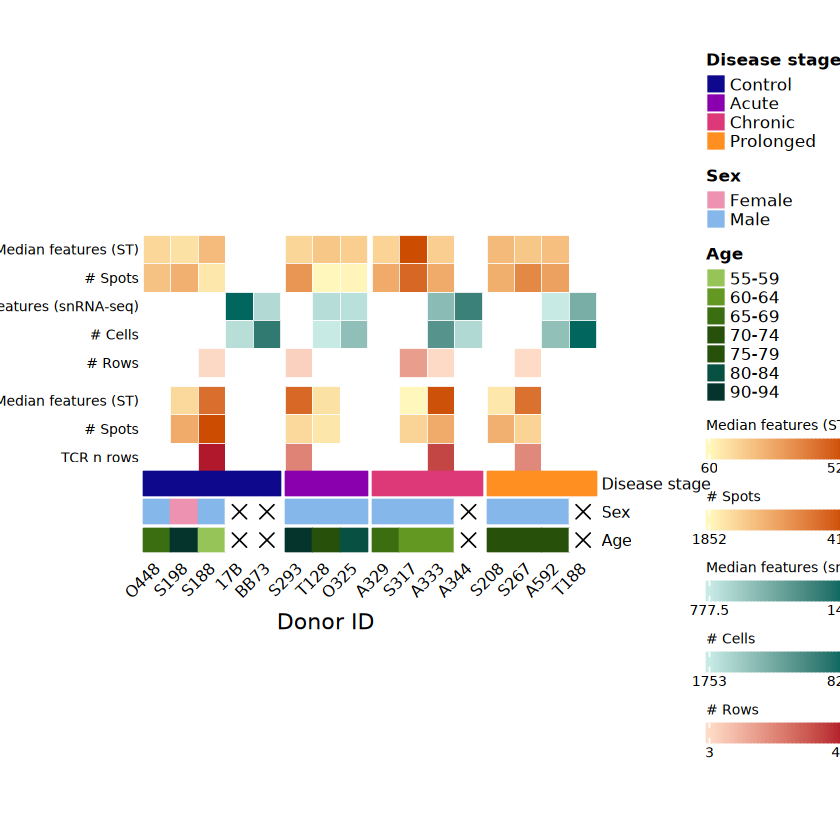

In [6]:
draw(ht_lung %v% ht_ln %v% ht_meta,
     column_title      = "Donor ID",
     column_title_side = "bottom",
     annotation_legend_list = list(lgd_disease, lgd_sex, lgd_age,
                                   lgd_st_features, lgd_st_nspots,
                                   lgd_sn_features, lgd_sn_ncells,
                                   lgd_tcr_rows),
     heatmap_legend_side    = "right",
     annotation_legend_side = "right")

## Session information

In [7]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/groups/singlecell/cvicente/miniconda3/envs/COVID/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats4    grid      stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] HDF5Array_1.38.0            h5mread_1.2.1              
 [3] rhdf5_2.54.1                DelayedArray_0.36.0        
 [5] SparseArray_1.10.8          S4Arrays_1.10.1            
 [7]